## Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Load Dataset

In [2]:
# Load dataset
data = pd.read_csv("traffic.csv")

# Preview data
print(data.head())

# Info
print(data.info())

              DateTime  Junction  Vehicles           ID
0  2015-11-01 00:00:00         1        15  20151101001
1  2015-11-01 01:00:00         1        13  20151101011
2  2015-11-01 02:00:00         1        10  20151101021
3  2015-11-01 03:00:00         1         7  20151101031
4  2015-11-01 04:00:00         1         9  20151101041
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   DateTime  48120 non-null  object
 1   Junction  48120 non-null  int64 
 2   Vehicles  48120 non-null  int64 
 3   ID        48120 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB
None


## Convert DateTime & Feature Engineering

In [3]:
# Convert DateTime
data["DateTime"] = pd.to_datetime(data["DateTime"])

# Extract features
data["hour"] = data["DateTime"].dt.hour
data["day"] = data["DateTime"].dt.day
data["month"] = data["DateTime"].dt.month
data["weekday"] = data["DateTime"].dt.weekday

# Weekend feature
data["is_weekend"] = data["weekday"].apply(lambda x: 1 if x >= 5 else 0)

print(data.head())

             DateTime  Junction  Vehicles           ID  hour  day  month  \
0 2015-11-01 00:00:00         1        15  20151101001     0    1     11   
1 2015-11-01 01:00:00         1        13  20151101011     1    1     11   
2 2015-11-01 02:00:00         1        10  20151101021     2    1     11   
3 2015-11-01 03:00:00         1         7  20151101031     3    1     11   
4 2015-11-01 04:00:00         1         9  20151101041     4    1     11   

   weekday  is_weekend  
0        6           1  
1        6           1  
2        6           1  
3        6           1  
4        6           1  


## Basic Visualization (Traffic Over Time)

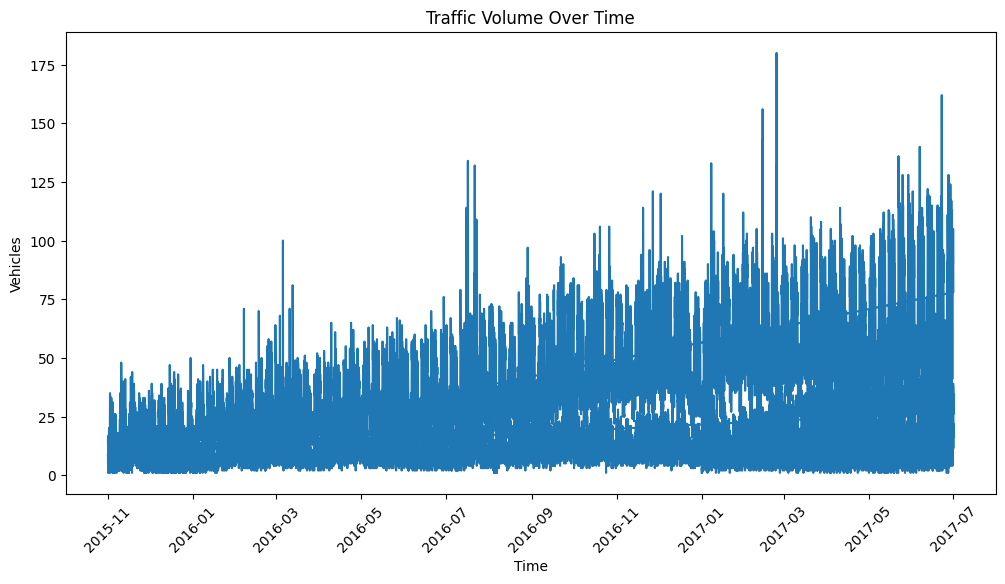

In [4]:
plt.figure(figsize=(12,6))

plt.plot(data["DateTime"], data["Vehicles"])

plt.xlabel("Time")
plt.ylabel("Vehicles")
plt.title("Traffic Volume Over Time")

plt.xticks(rotation=45)

plt.show()

## Traffic by Hour

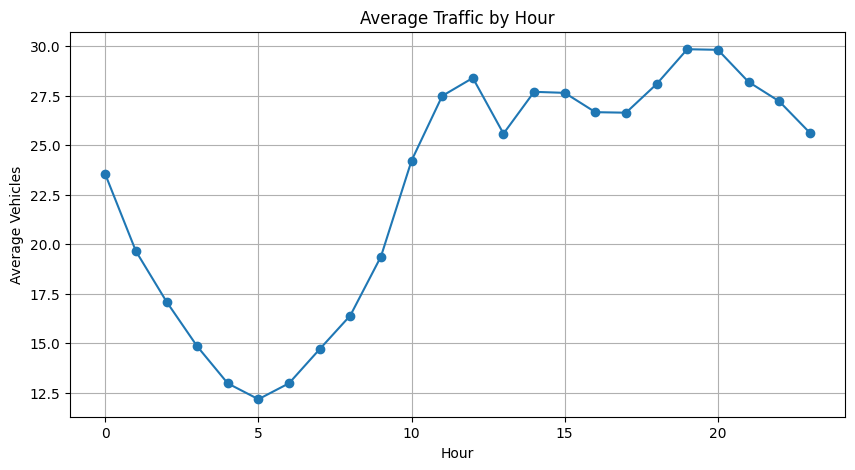

In [5]:
hourly_traffic = data.groupby("hour")["Vehicles"].mean()

plt.figure(figsize=(10,5))

plt.plot(hourly_traffic.index, hourly_traffic.values, marker='o')

plt.xlabel("Hour")
plt.ylabel("Average Vehicles")
plt.title("Average Traffic by Hour")

plt.grid(True)

plt.show()

## Heatmap

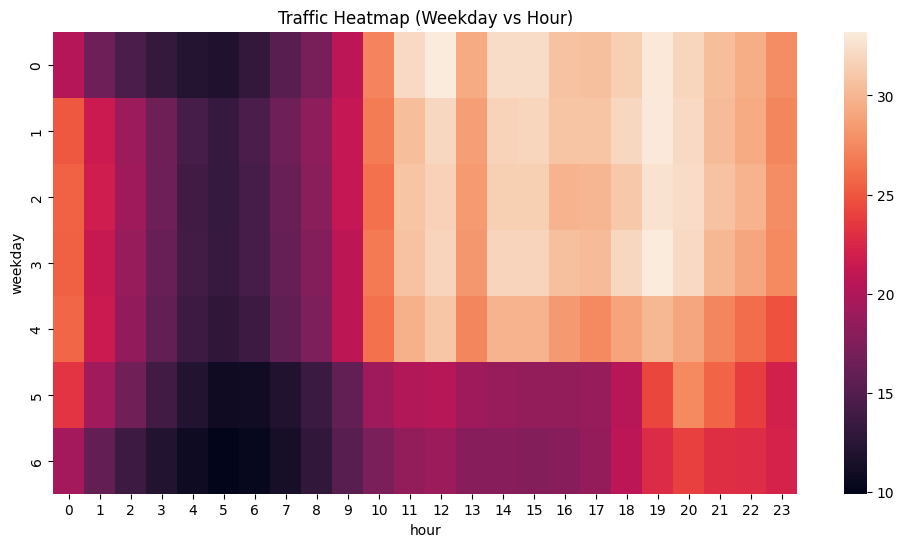

In [6]:
pivot = data.pivot_table(
    values="Vehicles",
    index="weekday",
    columns="hour",
    aggfunc="mean"
)

plt.figure(figsize=(12,6))

sns.heatmap(pivot)

plt.title("Traffic Heatmap (Weekday vs Hour)")

plt.show()

## Feature Selection

In [7]:
features = [
    "Junction",
    "hour",
    "day",
    "month",
    "weekday",
    "is_weekend"
]

X = data[features]
y = data["Vehicles"]

## Train Test Split


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Feature Scaling (IMPORTANT for SVM)

In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Train SVM Model

In [11]:
model = SVR(
    kernel='rbf',
    C=100,
    epsilon=0.1
)

model.fit(X_train_scaled, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


## Predictions

In [12]:
predictions = model.predict(X_test_scaled)

print(predictions[:10])

[ 6.65131238 13.03448435  8.33426885  9.83168815 26.18450651 14.72165696
  6.72077007 11.83118397 14.61128064 18.02717216]


## Model Evaluation

In [13]:
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 7.378232534340411
RMSE: 11.62940732704823
R2 Score: 0.6681531216000438


## Actual vs Predicted Graph

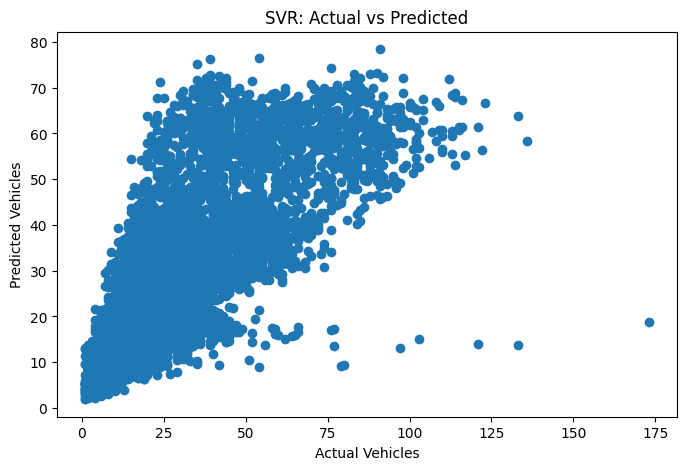

In [16]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Vehicles")
plt.ylabel("Predicted Vehicles")
plt.title("SVR: Actual vs Predicted")

plt.show()

## Predict New Input

In [17]:
sample = pd.DataFrame({
    "Junction": [2],
    "hour": [8],
    "day": [15],
    "month": [11],
    "weekday": [0],
    "is_weekend": [0]
})

sample_scaled = scaler.transform(sample)

prediction = model.predict(sample_scaled)

print("Predicted Vehicles:", prediction[0])

Predicted Vehicles: 10.83265871560397


## Convert to Congestion Level

In [18]:
def congestion_level(vehicles):
    if vehicles < 20:
        return "Low"
    elif vehicles < 60:
        return "Medium"
    else:
        return "High"

print("Traffic Level:", congestion_level(prediction[0]))

Traffic Level: Low
